# 第13章 平稳时间序列

## 13.1 时间序列的自相关

使用数据集gdp_china.dta考察在1978—2013年期间，中国的年度国内生产总值(1978年为不变价格，亿元)，记为y。


Time variable: year, 1978 to 2013
        Delta: 1 unit


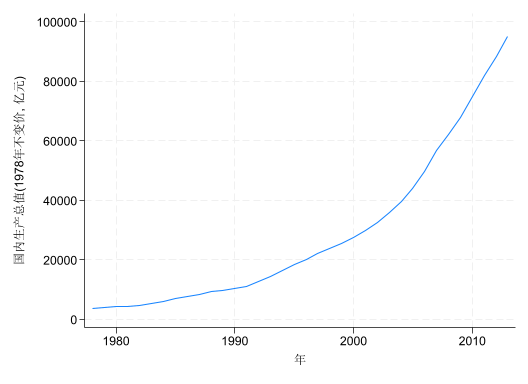

In [1]:
* 定义时间变量后，首先看GDP的时间趋势
use data/gdp_china.dta,clear
tsset year
* “tsline”表示画时间趋势图，在此等价于命令“line gdp year”(year为时间变量)
* 选择项“xlabel(1980(10)2010)”表示在横轴1980-2010年期间，每隔10年做个标注(label)。
tsline y,xlabel(1980(10)2010)

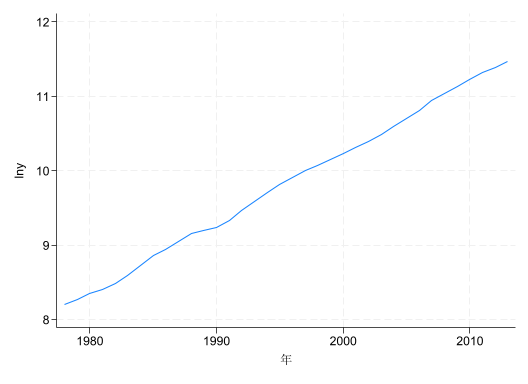

In [2]:
* 下面，计算GDP对数，并再次画时间趋势图
gen lny=log(y)
tsline lny,xlabel(1980(10)2010)

(1 missing value generated)


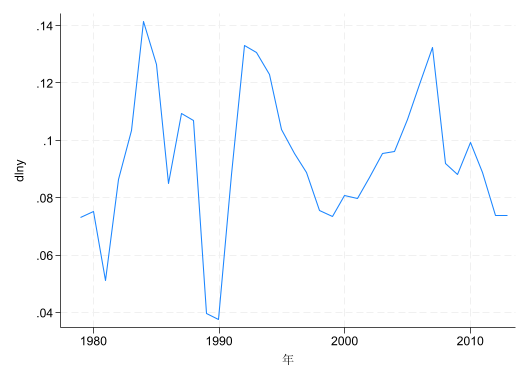

In [3]:
* 将GDP对数进行一阶差分(可使用Stata的差分算子“d.”),然后再画时间趋势图
gen dlny=d.lny
tsline dlny,xlabel(1980(10)2010)

(1 missing value generated)


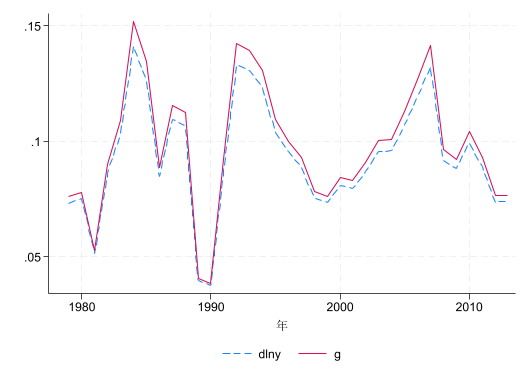

In [4]:
* 事实上，之所以考察GDP对数差分，是因为它约等于GDP的增长率。
* 下面直接计算GDP的增长率(记为g)，并与GDP对数差分进行画图比
gen g=(y-l.y)/l.y
tsline dlny g,xlabel(1980(10)2010) lp(dash)

In [5]:
* 下面，通过画自相关图，来考察GDP对数差分的各阶自相关系数。
corrgram dlny


                                          -1       0       1 -1       0       1
 LAG       AC       PAC      Q     Prob>Q  [Autocorrelation]  [Partial autocor]
-------------------------------------------------------------------------------
1        0.5360   0.5454   10.943  0.0009          |----              |----    
2       -0.0298  -0.4515   10.978  0.0041          |               ---|        
3       -0.2579   0.0205   13.669  0.0034        --|                  |        
4       -0.3405  -0.3311   18.514  0.0010        --|                --|        
5       -0.4687  -0.3671   27.998  0.0000       ---|                --|        
6       -0.4371  -0.3092   36.531  0.0000       ---|                --|        
7       -0.1425  -0.0790    37.47  0.0000         -|                  |        
8        0.1774  -0.0418    38.98  0.0000          |-                 |        
9        0.3220  -0.1600   44.143  0.0000          |--               -|        
10       0.2768  -0.0670   48.113  0.00

* 上表第1列表示滞后阶数(LAG)。
* 第2列表示自相关系数(AC)，而右边倒数第2列即为自相关图(以线条长度表示各阶自相关系数)。
* 上表第3列PAC为偏自相关系数(partial autocorrelation)，即在给定($y_{t+1},⋯,y_{t+k-1}$)的情况下，$y_t$与$y_{t+k}$的相关系数；而右边倒数第1列为PAC的图示。
* 上表第4-5列为Q统计量及其相应的p值(Prob>Q)，其原假设为“各阶自相关系数均为0”。比如，一阶Q统计量检验原假设“一阶自相关系数为0”，即
$H_0:\rho_1=0$；由于p值等于0.0009，故认为存在一阶自相关。二阶Q统计量则检验原假设“一阶与二阶自相关系数均为0”，即$H_0:\rho_1=\rho_2=0$；由于p值等于0.0041，故也拒绝一、二阶自相关系数均为0的原假设；以此类推。

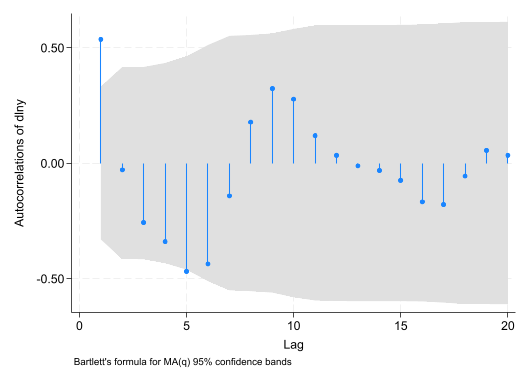

In [6]:
* Q统计量并不能告诉我们，二阶或更高阶自相关系数是否单独为0。为此，下面使用画自相关图的另一命令。
* “ac”表示 autocorrelation；
* 选择项“lags(20)”表示画1-20阶的自相关图，默认所画的最高阶数为min{floor(n/2)-2,40},其中floor(n/2)为不超过n/2的最大整数。
ac dlny,lags(20)

* 阴影部分表示置信区域(confidence band)；如果某阶自相关系数落在置信区域之外，则说明该阶自相关系数显著地不为0；反之，则不显著(接受该阶自相关系数为0的原假设)。
* 从图中可知，一阶与五阶自相关系数显著不为0，而其他阶的自相关系数不显著。

## 13.2 一阶自回归

使用过去值$y_{t-1}$来预测当前值$y_t$，即一阶自回归(first order autoregression, AR(1)):
$$
y_t=\beta_0+\beta_1 y_{t-1}+\epsilon_{t} \quad (t=2,\cdots,T)
$$
其中，扰动项$\epsilon_t$为白噪声，无自相关，即$Cov(\epsilon_t,\epsilon_s)=0,\forall t\neq s$。

继续上节的例子，以OLS估计$\Delta \ln y_t$的一阶自回归模型。为了演示目的，仅使用2013年以前的数据进行回归，然后预测2013年的 GDP。

In [7]:
reg dlny l.dlny if year<2013,r


Linear regression                               Number of obs     =         33
                                                F(1, 31)          =      12.99
                                                Prob > F          =     0.0011
                                                R-squared         =     0.2879
                                                Root MSE          =     .02147

------------------------------------------------------------------------------
             |               Robust
        dlny | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        dlny |
         L1. |   .5362727   .1487888     3.60   0.001     .2328159    .8397295
             |
       _cons |   .0437698   .0144049     3.04   0.005     .0143908    .0731488
------------------------------------------------------------------------------


从上表可得如下回归方程(常数项与斜率均在1%平上显著):
$$
\widehat{\Delta\ln y_t}=0.0437698+0.5362727\Delta\ln y_{t-1}
$$

下面，计算此回归方程的拟合值，即$\widehat{\Delta\ln y_t}$，并记为dlny1。

In [8]:
predict dlny1
list dlny1 if year==2013

(option xb assumed; fitted values)
(2 missing values generated)

     +---------+
     |   dlny1 |
     |---------|
 36. | .083309 |
     +---------+


因此，$\widehat{\Delta\ln y_{2013}}=0.083309$。由于$\widehat{\ln y_{2013}}=\ln y_{2012}+\widehat{\Delta\ln y_{2013}}$，故2013年GDP的预测值为$\widehat{y_{2013}}=\exp(\ln y_{2012}+\widehat{\Delta\ln y_{2013}})$。

In [9]:
* 在Stata中，可使用“x[n]”表示变量x的第n个观测值
dis exp(lny[35]+dlny1[36])

95985.114


In [10]:
* 对比2013年的实际GDP，并计算预测误
dis y[36]
dis y[36]-exp(lny[35]+dlny1[36])

95089.211
-895.90347


## 13.3 高阶自回归

考虑p阶自回归模型，记为AR(p):
$$
y_t=\beta_0+\beta_1y_{t-1}+\cdots+\beta_py_{t-p}+\epsilon_t
$$
其中，扰动项$\epsilon_t$为白噪声(无自相关)，故OLS为一致估计。

通常我们并不知道滞后期p。因此，如何估计$\hat p$在实践中有着重要的意义。

- 方法之一：设一个最大滞后期$p_{max}$，然后令$\hat p=p_{max}$。进行估计，并对最后一个滞后期系数的显著性进行t检验。如果接受该系数为0，则令$\hat p=p_{max}-1$，重新进行估计，再对(新的)最后一个滞后期的系数进行t检验，如果显著，则停止；否则，令$\hat p=p_{max}-2$；以此类推。此准则被称为由大到小的序贯t规则(general-to-specific sequential t rule)。
- 方法之二：使用信息准则，选择$\hat p$使得AIC或BIC最小化，分别记为$\hat p_{AIC}$与$\hat p_{BIC}$。比如：

$$
\min_{p} AIC=\ln\frac{SSR}{T}+\frac{2}{T}(p+1)
$$

其中，SSR为残差平方和。可以证明，$\hat p_{BIC}$是真实滞后阶数p的一致估计，但$\hat p_{AIC}$在大样本中可能高估p。

回到上节GDP对数差分的例子。首先，使用信息准则来确定滞后阶数p，即从AR(1)开始，分别计算AIC与BIC，然后逐次增加滞后阶数，直至AIC与BIC二者出现最小值并开始上升。

In [11]:
quietly reg dlny l.dlny if year<2013,r
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         33   75.35938   80.96115       2  -157.9223  -154.9293
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


由此可知，AR(1)的AIC为-157.9223，而BIC为-154.9293。下面估计AR(2)模型，并计算其信息准则。

In [12]:
* “1(1/2).dlny”表示变量dlny的1-2阶滞后。
reg dlny l(1/2).dlny if year<2013,r


Linear regression                               Number of obs     =         32
                                                F(2, 29)          =      17.51
                                                Prob > F          =     0.0000
                                                R-squared         =     0.4234
                                                Root MSE          =     .01979

------------------------------------------------------------------------------
             |               Robust
        dlny | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        dlny |
         L1. |   .7711595   .1304462     5.91   0.000     .5043671    1.037952
         L2. |  -.4487175   .1530057    -2.93   0.007    -.7616494   -.1357857
             |
       _cons |   .0641134   .0128498     4.99   0.000     .0378326    .0903943
---------------------------------------------------------------

从上表可知，dlny的二阶滞后L2.dlny依然在1%平上显著，故根据序贯t规则，滞后阶数p应至少大于或等于2。

In [13]:
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         32   72.88943   81.69936       3  -157.3987  -153.0015
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


由此可知，AR(2)的AIC为-157.3987，而BIC为-153.0015；均比AR(1)略有上升。故根据信息准则，应选择p=1，即AR(1)模型(尽管AR(1)仅比AR(2)有微弱优势)。下面进一步估计AR(3)模型。

In [14]:
reg dlny l(1/3).dlny if year<2013,r


Linear regression                               Number of obs     =         31
                                                F(3, 27)          =      12.82
                                                Prob > F          =     0.0000
                                                R-squared         =     0.4459
                                                Root MSE          =     .01907

------------------------------------------------------------------------------
             |               Robust
        dlny | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        dlny |
         L1. |   .7557034   .1261359     5.99   0.000     .4968939    1.014513
         L2. |  -.4943798   .1785691    -2.77   0.010    -.8607733   -.1279864
         L3. |   .0204783   .1711994     0.12   0.906    -.3307938    .3717504
             |
       _cons |   .0692315   .0154137     4.49   0.000     .0376

从上表可知，dlny的三阶滞后L3.dlny很不显著(p值高达0.906)，故根据序贯t规则，应选择p=2，即AR(2)模型。

In [15]:
estat ic


Akaike's information criterion and Bayesian information criterion

-----------------------------------------------------------------------------
       Model |          N   ll(null)  ll(model)      df        AIC        BIC
-------------+---------------------------------------------------------------
           . |         31   71.75641   80.90811       4  -153.8162  -148.0803
-----------------------------------------------------------------------------
Note: BIC uses N = number of observations. See [R] IC note.


In [16]:
* 下面使用AR(2)模型预测GDP，并与AR(1)模型的预测效果进行对比。
quietly reg dlny l(1/2).dlny if year<2013,r
predict dlny2
dis exp(lny[35]+dlny2[36])
dis y[36]-exp(lny[35]+dlny2[36])

(option xb assumed; fitted values)
(3 missing values generated)
95769.998
-680.78688


因此，对于2013年的GDP，AR(2)模型的预测误差为-680.78688亿元，即高估了680.78688亿元；而AR(1)模型则高估了895.90347亿元。显然，AR(2)的预测效果明显优于AR(1)，因为二阶滞后仍包含不少有用信息。

## 13.4 自回归分布滞后模型

在自回归AR(p)模型中，为了提高预测力或解释力，也可引入其他解释变量，构成自回归分布滞后模型(autoregressive distributed lag model, 简记ADL(p,q)或ARDL(p,q)):
$$
y_t=\beta_0+\beta_1y_{t-1}+\cdots+\beta_py_{t-p}+\gamma_1x_{t-1}+\cdots+\gamma_qx_{t-q}+\epsilon_t
$$
其中，p为被解释变量y的自回归阶数，而q为解释变量x的滞后阶数。假定扰动项$\epsilon_t$为白噪声，则OLS为一致估计。

由于$\{y_t\}$与$\{x_t\}$为平稳序列，故均值不随时间而变，记其均值分别为$y^*$与$x^*$。$x^*$增加一单位对$y^*$的边际效应为：
$$
\frac{dy^*}{dx^*}=\frac{\gamma_1+\cdots+\gamma_q}{1-\beta_1-\cdots-\beta_p}
$$
这就是解释变量x永久性增加一单位对y的长期效应，也称为长期乘数(long-run multiplier)。

作为ADL的实例，Chen(2015)研究了中原王朝与北方游牧民族边界维度(border)的决定因素。时间序列数据集border.dta以每十年作为观测单位(时间变量为decade)，从公元前221年秦朝建立至1911年清朝灭亡，共有213个观测值。主要解释变量为中原王朝早于游牧政权建立的年数(dif)，以及中国北方在十年中发生旱灾的年数比例(drought)。其他控制变量包括：中原王朝的绝对年龄(age)，游牧对手的数目(rival)，中原是否在长城的有效保护之下(wall)，以及中国是否统一(unified)。

信息准则与序贯检验均支持估计以下ADL(2,1)模型：
$$
\text{border}_t=\beta_0+\beta_1\text{border}_{t-1}+\beta_2\text{border}_{t-2}+\gamma_1\text{drought}_{t-1}+\gamma_2\text{diff}_t+\gamma_3\text{age}_t+\gamma_4\text{rival}_t+\gamma_5\text{wall}_t+\gamma_6\text{unified}_t+\epsilon_t
$$
其中，变量diff,age,rival,wall与unified被认为只有当期作用，而气候变量drought则存在滞后效应。

In [17]:
use data/border.dta, clear
tsset decade
reg border l(1/2).border l.drought diff age rival wall unified,r


Time variable: decade, -22 to 190
        Delta: 1 unit

Linear regression                               Number of obs     =        211
                                                F(8, 202)         =    2040.71
                                                Prob > F          =     0.0000
                                                R-squared         =     0.9854
                                                Root MSE          =     1.0889

------------------------------------------------------------------------------
             |               Robust
      border | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      border |
         L1. |   1.518284    .133108    11.41   0.000     1.255825    1.780744
         L2. |  -.5586965   .1278243    -4.37   0.000    -.8107376   -.3066555
             |
     drought |
         L1. |  -.6333046   .3009855    -2.10   0.037    -1.226781   -

* 从上表可知，被解释变量的两阶滞后(L1.border与L2.border)均在1%平上显著。
* 变量L1.drought在5%平上显著为负，说明气候越干旱，游牧民族越会为了生存而进攻中原王朝，从而将游牧边界推向南方。
* 变量diff也在5%水平上显著为负，说明中原王朝越早于游牧政权建立(根据王朝周期假说，中原相对更弱)，北方边界纬度越低。
* 其他控制变量也至少在10%平上显著，而且系数符号均与理论预期一致。

从上表还可计算气候冲击对游牧边界的长期效应。假如drought永久性增加一单位，即从0增加到1(从年年无灾到年年旱灾)，则中国北方边界纬度将变化$\gamma_1/(1-\beta_1-\beta_2)$度。

In [18]:
dis -.6333046/(1-1.518284+.5586965)

-15.671008


根据此模型，气候冲击对游牧边界的长期效应为15.67度，这是一个很大的效应(从北京到海口的纬度差距约为20度)。

## 13.7 脉冲响应函数

$$
IRF(j)=\frac{\partial y_{t+j}}{\partial \epsilon_t}=\beta_1^j
$$
其中，$(\partial y_{t+j}/\partial \epsilon_t)$表示，当第t期的扰动项$\epsilon_t$变化1单位时(而其他期的扰动项均不变),对相隔j期的$y_{t+j}$的影响，被称为动态乘子(dynamic multiplier)。将$(\partial y_{t+j}/\partial \epsilon_t)$视为j的函数，称为脉冲响应函数(impulse response function, 简记IRF)，它刻画的是$y_{t+j}$对$\epsilon_t$的1单位脉冲(impulse)的响应(response)。

估计向量自回归(vector autogression, VAR)模型的Stata命令为：
```
varbasic x y z,lags(numlist)irf
```
- “x y z”为VAR模型所包含的变量。
- 选择项“lags(numlist)”表示滞后阶数，默认为“lags(1 2)”或“lags(1/2)”，即滞后二阶。
- 选择项“irf”表示画脉冲响应图。

(1 missing value generated)

Vector autoregression

Sample: 1980 thru 2012                          Number of obs     =         33
Log likelihood =   80.96115                     AIC               =  -4.785524
FPE            =   .0004889                     HQIC              =  -4.755008
Det(Sigma_ml)  =   .0004331                     SBIC              =  -4.694827

Equation           Parms      RMSE     R-sq      chi2     P>chi2
----------------------------------------------------------------
dlny                  2     .021471   0.2879   13.34017   0.0003
----------------------------------------------------------------

------------------------------------------------------------------------------
        dlny | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
dlny         |
        dlny |
         L1. |   .5362727   .1468267     3.65   0.000     .2484976    .8240478
             |
       _c

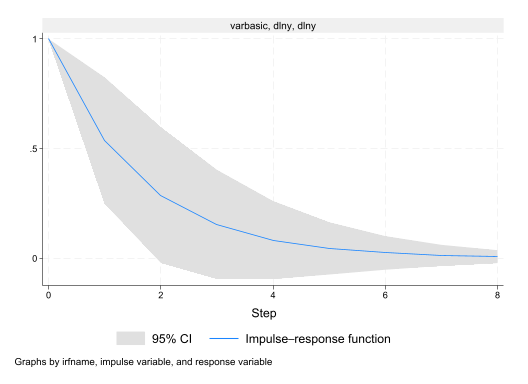

In [19]:
* 首先，估计dlny的AR(1)模型(为保持与上文的一致，不包括2013年的观测值)，并将其脉冲响应函数画图。
use data/gdp_china.dta,clear
gen lny=log(y)
gen dlny=d.lny
varbasic dlny if year<2013,lags(1) irf

使用命令“varbasic”的估计系数与命令“reg dlngdp 1.dlngdp”完全相同，只是命令“varbasic”不提供异方差稳健标准误的选择项(时间序列一般不存在异方差问题)。

从图中可知，AR(1)模型的脉冲响应函数呈指数衰减，从当期的一单位冲击逐渐衰减为0，与IRF表达式一致。其中，灰色区域为IRF的95%信区间。


Vector autoregression

Sample: 1981 thru 2012                          Number of obs     =         32
Log likelihood =   81.69936                     AIC               =   -4.91871
FPE            =   .0004282                     HQIC              =  -4.873162
Det(Sigma_ml)  =   .0003548                     SBIC              =  -4.781298

Equation           Parms      RMSE     R-sq      chi2     P>chi2
----------------------------------------------------------------
dlny                  3     .019785   0.4234   23.49854   0.0000
----------------------------------------------------------------

------------------------------------------------------------------------------
        dlny | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
dlny         |
        dlny |
         L1. |   .7711595   .1593746     4.84   0.000      .458791    1.083528
         L2. |  -.4487175    .157661    -2.85   0.00

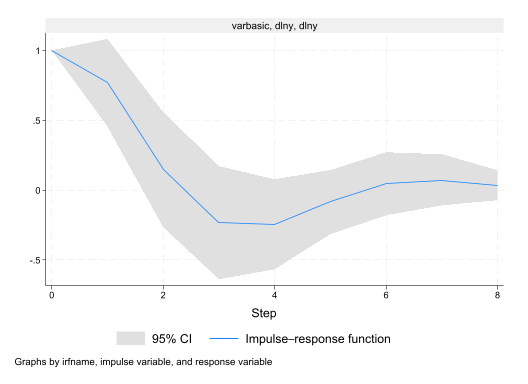

In [20]:
* 其次，估计dlny的AR(2)模型，并将其IRF画图
varbasic dlny if year<2013,irf

从图中可知，AR(2)模型的脉冲响应函数不再单调递减，更具动态特征，即先下降，变为负数后再反弹上升，然后又下降并趋于0。

## 13.10 格兰杰因果检验

经济学中常常需要确定因果关系究竟是从x到y，还是从y到x，抑或是双向因果关系。为此，Granger(1969)提出了格兰杰因果检验(Granger causality test)

考虑以下ADL(p,p)模型：
$$
y_t=\gamma+\sum_{m=1}^p\alpha_m y_{t-m}+\sum_{m=1}^p\beta_m x_{t-m}+\epsilon_t
$$
估计此模型后，可检验原假设$H_0:\beta_1=\cdots=\beta_p=0$，即x的过去值对预测y的未来值有无帮助。如果拒绝$H_0$，则称x是y的格兰杰因(Granger cause)。将以上回归模型中x与y的位置互换，则可以检验y是否为x的格兰杰因。

## 13.11 VAR的Stata命令及实例

与VAR相关的Stata命令包括(假设变量为x,y,z)：

```
varsoc x y z,maxlag(#)
```
此命令用来计算不同滞后期的信息准则，其中“soc”表示selection-order criteria，选择项“maxlag(#)”表示最大滞后期，默认值为4。在未使用选择项“maxlag(#)”的情况下，如果恰好选择最优滞后4期，则应通过选择项“maxlag(#)增加最大滞后期数。

```
varbasic x y z,lags(numlist) irf
```
这是估计VAR模型的便捷命令。选择项“lags(numlist)”表示滞后阶数，默认为“lags(12)”或“lags(1/2)”，即滞后二阶。选择项“irf”表示画(未正交化)脉冲响应图，默认为“oirf”(画正交化脉冲响应图)。

估计VAR的正式命令为
```
var x y z,lags(numlist) exog(w1 w2)
```
其中，选择项“lags(numlist)”表示滞后阶数，默认为“lags(1/2)”，即滞后二阶。如果要滞后三阶，可使用选择项“lags(1/3)”。选择项“exog(w1w2)”表示在VAR模型中引入外生变量w1与w2。

```
varlmar,mlag(#)
```
估计VAR后，对残差是否存在自相关进行LM检验。其中，选择项“mlag(#)”指定所检验自相关的最大滞后阶数(maximum order of autocorrelation)，默认为“mlag(2)”。

```
varstable,graph
```
估计VAR后，通过特征值检验该VAR系统是否为平稳过程。如果所有特征值都在单位圆内部，则为平稳过程。选择项“graph”表示画出特征值的几何分布图。

```
varwle
```
估计VAR后，对每个方程以及所有方程的各阶系数的联合显著性进行沃尔德检验，其中“wle”表示Wald lag-exclusion statistics。

```
vargranger
```
估计VAR后，进行格兰杰因果检验。

```
irf create irfname,set(filename) step(#) replace order(varlist)
```
估计VAR后，将有关脉冲响应的结果存为“irfname”(可自行命名)。选择项“set(filename)”表示建立脉冲文件"filename"，使之成为当前的脉冲文件(make filename active)，并将脉冲结果“irfname”存入此脉冲文件“filename”；选择项“step(#)”表示考察截至#期的脉冲响应函数，默认为“step(8)”；选择项“replace”表示替代已有的同名脉冲响应结果“irfname”(如果有)。选择项“order(varlist)”指定变量排序，默认使用估计VAR时的变量排序计算正交化IRF。

```
irf graph irf,impulse(varname) response(varname)
```
画脉冲响应图(未正交化)。其中，选择项“impulse(varname)”用于指定脉冲变量，而选择项“response(varname)”用来指定反应变量；默认画出所有变量的脉冲响应图。

```
irf graph oirf,impulse(varname) response(varname)
```
画正交化的脉冲响应图，选择项的含义同上。

如果将以上命令中的“irf graph”改为“irf table”，则将相应信息列表而非画图。

```
fcast compute prefix,step(#)
```
估计VAR后，计算被解释变量未来#期的预测值，并把预测值赋予被解释变量加上前缀“prefix”(自行确定)的变量名。

```
fcast graph varlist,observed
```
运行命令“fcast compute”后，将变量“varlist”的预测值画图，其中选择项“observed”表示与实际观测值相比较。


下面以数据集macro_swatson.dta为例，进行VAR估计。该数据集包含美国1960年第2季至2002年第1季的以下宏观经济季度变量：
- inf为通货膨胀率，
- dinf为通货膨胀率的一阶差分，
- unem为失业率，
- quarter为季度(时间变量)。

由于通货膨胀率inf可能不平稳，故考虑其一阶差分dinf与失业率unem所构成的二元VAR系统。

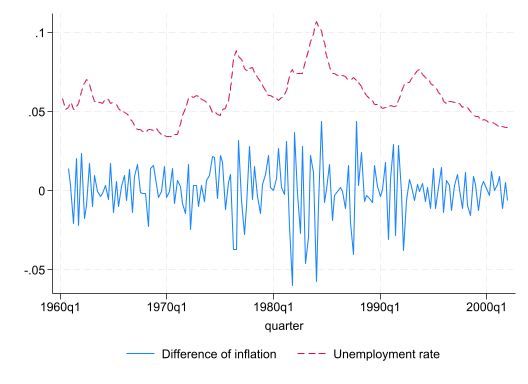

In [21]:
* 首先，打开数据集后，看一下二者的时间趋势
use data/macro_swatson.dta,clear
tsline dinf unem,lp(solid dash)

In [22]:
* 其次，根据信息准则，估计此VAR系统的阶数。
varsoc dinf unem


Lag-order selection criteria

   Sample: 1961q4 thru 2002q1                              Number of obs = 162
  +---------------------------------------------------------------------------+
  | Lag |    LL      LR      df    p     FPE       AIC      HQIC      SBIC    |
  |-----+---------------------------------------------------------------------|
  |   0 |  881.581                     6.6e-08   -10.859  -10.8435  -10.8209  |
  |   1 |   1141.4  519.63    4  0.000 2.8e-09  -14.0172  -13.9708  -13.9029  |
  |   2 |  1213.86  144.93*   4  0.000 1.2e-09* -14.8625* -14.7851* -14.6719* |
  |   3 |  1217.32  6.9224    4  0.140 1.2e-09  -14.8558  -14.7475   -14.589  |
  |   4 |  1219.45  4.2537    4  0.373 1.2e-09  -14.8327  -14.6934  -14.4896  |
  +---------------------------------------------------------------------------+
   * optimal lag
   Endogenous: dinf unem
    Exogenous: _cons


结果显示，当p=2时(上表中打星号“*”者),AIC与BIC信息准则最小化。

In [23]:
* 下面，估计二阶向量自回归模型。
var dinf unem,lags(1/2)


Vector autoregression

Sample: 1961q2 thru 2002q1                      Number of obs     =        164
Log likelihood =   1224.456                     AIC               =  -14.81044
FPE            =   1.27e-09                     HQIC              =  -14.73371
Det(Sigma_ml)  =   1.12e-09                     SBIC              =  -14.62143

Equation           Parms      RMSE     R-sq      chi2     P>chi2
----------------------------------------------------------------
dinf                  5     .013815   0.3621   93.11047   0.0000
unem                  5     .002508   0.9731   5926.554   0.0000
----------------------------------------------------------------

------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
dinf         |
        dinf |
         L1. |  -.4709436   .0676118    -6.97   0.000    -.6034603

In [24]:
* 上表显示，大多数的系数均很显著。下面检验各阶系数的联合显著性。
varwle


   Equation: dinf
  +------------------------------------+
  | lag |    chi2      df  Prob > chi2 |
  |-----+------------------------------|
  |   1 |  72.72164     2     0.000    |
  |   2 |   72.9294     2     0.000    |
  +------------------------------------+

   Equation: unem
  +------------------------------------+
  | lag |    chi2      df  Prob > chi2 |
  |-----+------------------------------|
  |   1 |  741.8916     2     0.000    |
  |   2 |  123.1287     2     0.000    |
  +------------------------------------+

   Equation: All
  +------------------------------------+
  | lag |    chi2      df  Prob > chi2 |
  |-----+------------------------------|
  |   1 |  796.2418     4     0.000    |
  |   2 |  187.9991     4     0.000    |
  +------------------------------------+


从上表可知，无论是单一方程(dinf与unem)，还是两个方程作为整体(A1l)，各阶系数均高度显著。

In [25]:
* 面检验残差是否为白噪声，即残差是否存在自相关。
varlmar


   Lagrange-multiplier test
  +--------------------------------------+
  | lag  |      chi2    df   Prob > chi2 |
  |------+-------------------------------|
  |   1  |    7.3130     4     0.12024   |
  |   2  |    5.0645     4     0.28074   |
  +--------------------------------------+
   H0: no autocorrelation at lag order


结果显示，可以接受残差“无自相关”的原假设。


   Eigenvalue stability condition
  +----------------------------------------+
  |        Eigenvalue        |   Modulus   |
  |--------------------------+-------------|
  |     .82182               |    .82182   |
  |   .7970223               |   .797022   |
  |  -.2258777 +  .6292178i  |   .668533   |
  |  -.2258777 -  .6292178i  |   .668533   |
  +----------------------------------------+
   All the eigenvalues lie inside the unit circle.
   VAR satisfies stability condition.


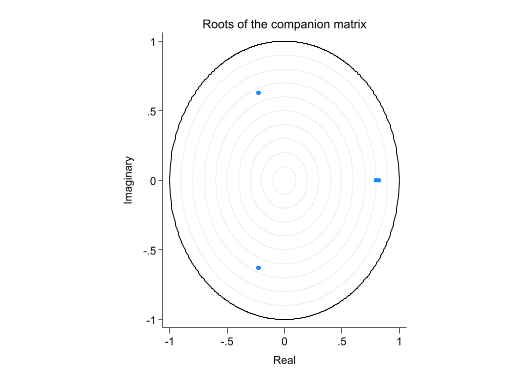

In [26]:
* 进一步检验估计出来的VAR系统是否为平稳过程，并画图
varstable,graph

* 上表最后两行显示，所有特征值均在单位圆之内，故此VAR模型满足平稳性条件。
* 图中直观地显示，所有特征值均在单位圆之内，故此VAR系统是稳定的。

In [27]:
* 下面考察变量dinf与unem之间的格兰杰因果关系。
vargranger


   Granger causality Wald tests
  +------------------------------------------------------------------+
  |          Equation           Excluded |   chi2     df Prob > chi2 |
  |--------------------------------------+---------------------------|
  |              dinf               unem |  48.123     2    0.000    |
  |              dinf                ALL |  48.123     2    0.000    |
  |--------------------------------------+---------------------------|
  |              unem               dinf |   9.009     2    0.011    |
  |              unem                ALL |   9.009     2    0.011    |
  +------------------------------------------------------------------+


无论以dinf还是unem为被解释变量，其p值均远小于0.05，二者互为格兰杰原因。因此，格兰杰因果检验无法提供变量排序的信息。

In [28]:
* 下面考察正交化脉冲响应函数，将脉冲文件命名为“macro”，并将脉冲结果命令为“iu”(表示变量排序为dinf,unem)。
* 选择项“replace”表示，若已有同名脉冲结果，可覆盖之
irf create iu, set(macro) replace

(file macro.irf created)
(file macro.irf now active)
(irfname iu not found in macro.irf)
(file macro.irf updated)


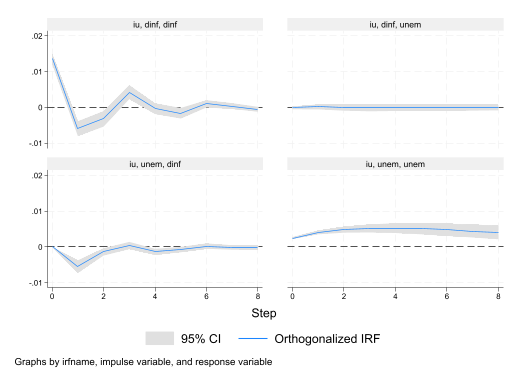

In [29]:
* 下面，根据此脉冲结果，画正交化的脉冲响应图
* 选择项“yline(0)”表示在纵轴y=0处画一条水平线
irf graph oirf,yline(0)

图中的最后一行为“Graphs by irfname,impluse variable,andresponse variable"，这表明四个小图的标题命名顺序为“脉冲名称、冲击变量、响应变量”。比如，左下小图的标题为“iu,unem,dinf”，表明此图为根据脉冲结果iu，冲击变量unem，响应变量dinf所画的脉冲响应图。它表明，失业率unem一个标准差的正向冲击，将使未来一期的通货膨胀率dinf下降，但未来二期的dinf即反弹，然后此影响逐渐消失归于0。

In [30]:
* 下面变换变量次序，考察正交化脉冲响应函数的稳健性。
* 选择项“order(unem dinf)”表示变量unem排在dinf之前。此命令将脉冲结果记为“ui”
irf create ui, order(unem dinf) replace

(irfname ui not found in macro.irf)
(file macro.irf updated)


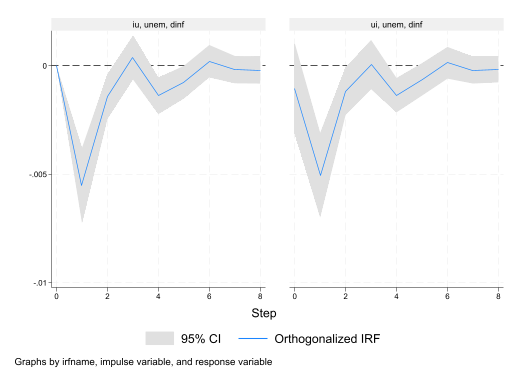

In [31]:
* 以上两个脉冲结果iu与ui,都已存储在当前脉冲文件“macro.irf”中；
* 故可直接画图，比较在两种变量排序下，dinf对于unem冲击的脉冲响应
irf graph oirf,i(unem) r(dinf) yline(0)

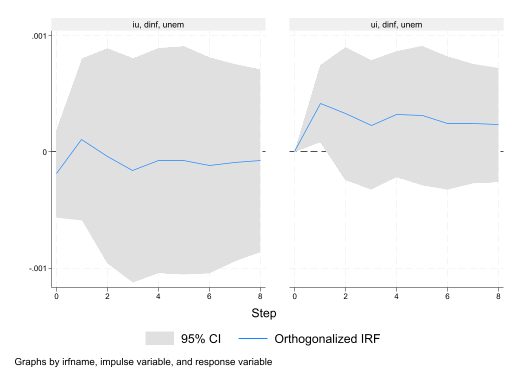

In [32]:
irf graph oirf,i(dinf) r(unem) yline(0)

In [33]:
varbasic dinf unem if quarter<tq(1999q1),lags(1/2) nograph


Vector autoregression

Sample: 1961q2 thru 1998q4                      Number of obs     =        151
Log likelihood =   1118.534                     AIC               =  -14.68256
FPE            =   1.44e-09                     HQIC              =  -14.60139
Det(Sigma_ml)  =   1.26e-09                     SBIC              =  -14.48274

Equation           Parms      RMSE     R-sq      chi2     P>chi2
----------------------------------------------------------------
dinf                  5     .014258   0.3673   87.65165   0.0000
unem                  5     .002585   0.9705   4971.522   0.0000
----------------------------------------------------------------

------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
dinf         |
        dinf |
         L1. |  -.4718995   .0702018    -6.72   0.000    -.6094925

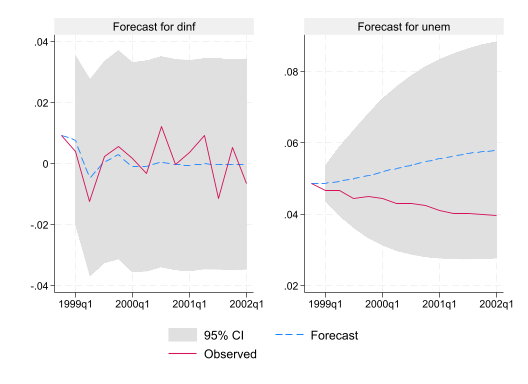

In [34]:
fcast compute f_,step(13)
* 选择项“observed”表示显示变量的实际观测值，
* 而选择项“1p(dash)”表示以虚线来画变量的预测值
fcast graph f_dinf f_unem,observed lp(dash)

图中表明，对通货膨胀率变动的预测准确度优于对失业率的预测，而二者的实际观测值均落在预测值95%置信区间内。另外，可以看出，预测的时期越长，预测的精确度越低。

## 13.12 时间趋势项

假设时间序列$\{y_t\}$包含时间趋势，则其不是平稳过程(期望随时间而变)。一种处理方法为做差分(或者先取对数，再差分)，将其变为平稳过程。但是，有时我们想直接对原变量$y_t$建模，则一种常见做法为，在回归方程中引入“线性时间趋势项”(linear time trend):
$$
y_t=\alpha+\beta t+\epsilon_t
$$
其中，$t=1,2,\cdots,T$为时间趋势项(T为样本容量)。

是否应引入时间趋势的平方项$t^2$，可通过检验$H_0:\gamma=0$来判断。但加入时间趋势的平方项，可能导致多重共线性。比如，假设样本容量为100，则可在Stata中计算时间趋势$t$及其平方项$t^2$的相关系数，如下所示。

In [35]:
clear
set obs 100
gen t=_n
gen t2=t^2
corr t t2

Number of observations (_N) was 0, now 100.
(obs=100)

             |        t       t2
-------------+------------------
           t |   1.0000
          t2 |   0.9689   1.0000



从上表可知，$t$与$t^2$的相关系数接近0.97，存在严重的多重共线性。因此，最常见的做法是仅包含线性趋势项，以避免出现多重共线性。

继续以数据集gdp_china.dta为例。考虑直接对GDP对数(lny)建模，即估计lny的AR(2)模型，并加上时间趋势项。

In [36]:
use data/gdp_china.dta,clear
gen t=_n
gen lny=log(y)
reg lny l(1/2).lny t if year<2013,r


Linear regression                               Number of obs     =         33
                                                F(3, 29)          =   38047.85
                                                Prob > F          =     0.0000
                                                R-squared         =     0.9997
                                                Root MSE          =     .01627

------------------------------------------------------------------------------
             |               Robust
         lny | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         lny |
         L1. |   1.302829   .1150665    11.32   0.000     1.067491    1.538166
         L2. |  -.7357654   .0967217    -7.61   0.000    -.9335835   -.5379473
             |
           t |   .0411649   .0092175     4.47   0.000      .022313    .0600168
       _cons |   3.473641   .7552359     4.60   0.000     1.929

从上表可知，lny的两阶滞后以及时间趋势项都高度显著。

下面，预测GDP对数，并记为lny3，然后计算2013年的预测误差。

In [37]:
predict lny3
dis exp(lny3[36])
dis y[36]-exp(lny3[36])

(option xb assumed; fitted values)
(2 missing values generated)
95597.887
-508.67625


因此，lny的“AR(2)+时间趋势项”模型的预测误差为-508.67625亿元，即高估了508.67625亿元；而dlny的AR(2)模型的预测高估了680.78688亿元。在此例中，直接对GDP对数(lny)建模并引入时间趋势项，其预测能力优于对GDP对数差分(dlny)的平稳过程建模。

## 13.13 季节调整

### 回归法

回归法的基本步骤为，首先生成月度(或季度)虚拟变量，然后把时间序列对这些虚拟变量进行OLS回归，所得残差就是经季节调整后的序列。

下面以airpassengers.dta为例，该数据集包括1949-1960年国际航空旅客人数的月度数据(airpassengers)与时间变量(time)。


Time variable: time, 1949m1 to 1960m12
        Delta: 1 month


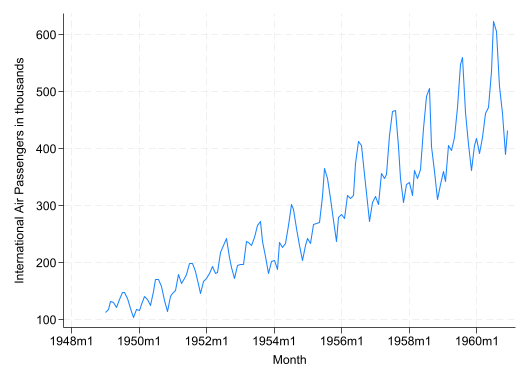

In [38]:
* 开数据集后，首先看一下aipassengers的时间趋势
use data/airpassengers.dta,clear
tsset time
tsline airpassengers

从图中可知，国际航空旅客人数存在明显的季节波动，通常在夏季(7、8月)达到高峰。

为了生成月度虚拟变量，首先从时间变量time中提取月度信息，记为变量month。

In [39]:
* “dofm(time)”将time转换为数值型，即从1960年1月1日至该月月初过了几天
gen month=month((dofm(time)))
* 其次，使用命令“tab”来生成季度虚拟变量。
* 选择项“gen(m)”表示，根据变量month的不同取值，生成相应的虚拟变量，记为m1,m2,⋯,m12,分别对应于12个月。
tab month,gen(m)


      month |      Freq.     Percent        Cum.
------------+-----------------------------------
          1 |         12        8.33        8.33
          2 |         12        8.33       16.67
          3 |         12        8.33       25.00
          4 |         12        8.33       33.33
          5 |         12        8.33       41.67
          6 |         12        8.33       50.00
          7 |         12        8.33       58.33
          8 |         12        8.33       66.67
          9 |         12        8.33       75.00
         10 |         12        8.33       83.33
         11 |         12        8.33       91.67
         12 |         12        8.33      100.00
------------+-----------------------------------
      Total |        144      100.00


In [40]:
* 然后，以1月份为参照值，把变量airpassengers对第2~12月的月度虚拟变量进行回归。
reg airpassengers m2-m12


      Source |       SS           df       MS      Number of obs   =       144
-------------+----------------------------------   F(11, 132)      =      1.42
       Model |  218382.243        11  19852.9312   Prob > F        =    0.1690
    Residual |  1839661.92       132  13936.8327   R-squared       =    0.1061
-------------+----------------------------------   Adj R-squared   =    0.0316
       Total |  2058044.16       143  14391.9172   Root MSE        =    118.05

------------------------------------------------------------------------------
airpasseng~s | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
          m2 |      -6.75   48.19549    -0.14   0.889    -102.0854    88.58545
          m3 |   28.41667   48.19549     0.59   0.556    -66.91878    123.7521
          m4 |   25.33333   48.19549     0.53   0.600    -70.00211    120.6688
          m5 |   30.08333   48.19549     0.62   0.

在上表中，7、8两月的虚拟变量(m7与m8)均在5%水平上显著为正；而其他月份的虚拟变量则不显著。

为了获得经季度调整的序列，下面使用命令“predict”来获得上述回归的残差项(记为air_sa)。

In [41]:
predict air_sa,r
sum airpassengers


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
airpasseng~s |        144    280.2986    119.9663        104        622


然而，OLS残差项的平均值一定为0，故需要把原序列的均值加回去，并记季节调整序列为“airpassengers_sa”。

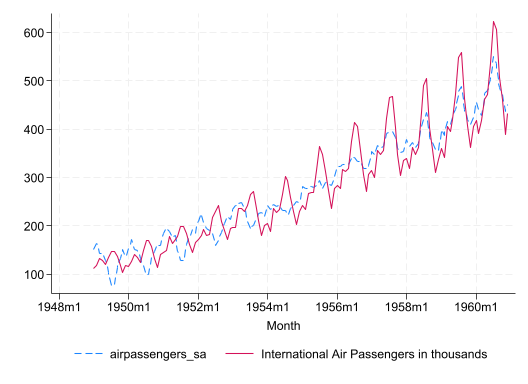

In [42]:
gen airpassengers_sa = air_sa+r(mean)
* 下面，将回归法的季节调整序列与原序列画图
tsline airpassengers_sa airpassengers,lp(dash)

从图中可知，经回归法进行季节调整后，序列变得更为光滑，季节性波动的特征有所减弱。